In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
stock = pd.read_csv("../data/raw/yfinance_data/data/AAPL.csv")
stock.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [3]:
stock['Date'] = pd.to_datetime(stock['Date'])
stock = stock.sort_values('Date')

In [4]:
stock['SMA_20'] = stock['Close'].rolling(window=20).mean()
stock['SMA_50'] = stock['Close'].rolling(window=50).mean()

In [5]:
stock['SMA_20'] = stock['Close'].rolling(window=20).mean()
stock['SMA_50'] = stock['Close'].rolling(window=50).mean()

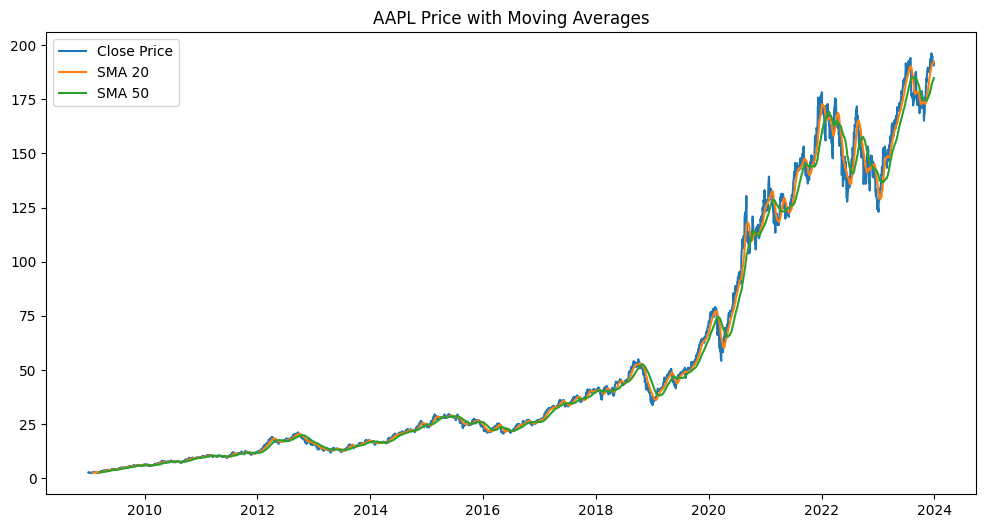

In [6]:
plt.figure(figsize=(12,6))
plt.plot(stock['Date'], stock['Close'], label='Close Price')
plt.plot(stock['Date'], stock['SMA_20'], label='SMA 20')
plt.plot(stock['Date'], stock['SMA_50'], label='SMA 50')
plt.legend()
plt.title("AAPL Price with Moving Averages")
plt.show()

In [7]:
from ta.momentum import RSIIndicator

stock['RSI'] = RSIIndicator(close=stock['Close'], window=14).rsi()

In [8]:
from ta.trend import MACD

macd = MACD(stock['Close'])
stock['MACD'] = macd.macd()
stock['MACD_signal'] = macd.macd_signal()

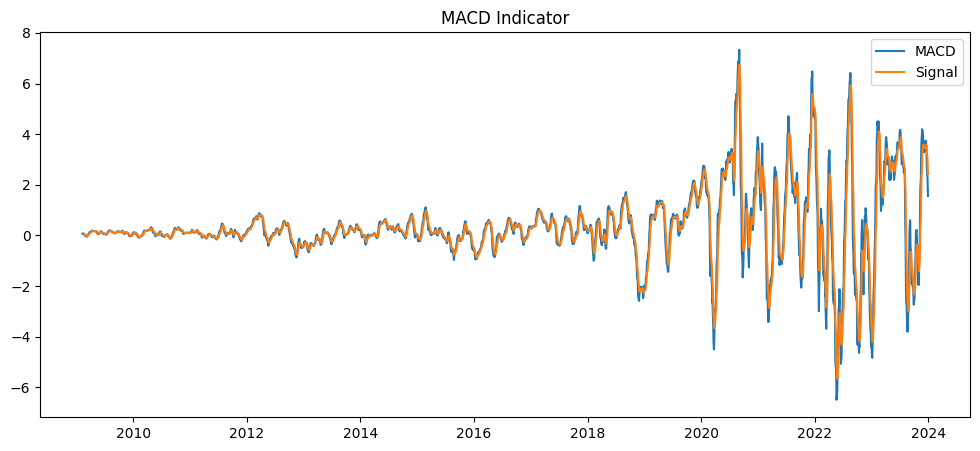

In [9]:
plt.figure(figsize=(12,5))
plt.plot(stock['Date'], stock['MACD'], label='MACD')
plt.plot(stock['Date'], stock['MACD_signal'], label='Signal')
plt.legend()
plt.title("MACD Indicator")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(news['headline_length'], bins=50)
plt.title("Distribution of News Headline Length")
plt.show()